# Neurosymbolic IoT Attack Detection — Module 1: Autoencoder-Based Anomaly Detection

**Replication of:** *Neurosymbolic learning and domain knowledge-driven explainable AI for enhanced IoT network attack detection and response*  
Kalutharage et al., Computers & Security 151 (2025) 104318

---

## Architecture (from Section 4.2)
- Fully connected autoencoder
- Hidden layers: **10 and 32 neurons**
- Activation: **ReLU**
- Optimizer: **Adam**
- Epochs: **40**
- Learning rate: **0.01**
- Anomaly metric: **MAE (Mean Absolute Error)**
- Threshold: **Max MAE on benign training data**

## Dataset
**USBIDS** — 17 labeled CSV files captured via CIC FlowMeter  
- 1 benign file (training data)
- 16 attack files (testing data)


## 0. Install / Import Libraries

In [1]:
# Standard installs available on Kaggle — no pip needed
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print(f'TensorFlow version: {tf.__version__}')
print(f'NumPy version:      {np.__version__}')
print(f'Pandas version:     {pd.__version__}')

2026-07-22 22:53:39.782952: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784760820.128553      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784760820.232679      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784760821.027336      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784760821.027396      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784760821.027400      16 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
NumPy version:      2.0.2
Pandas version:     2.3.3


## 1. Configuration


In [2]:
DATA_DIR = '/kaggle/input/datasets/anamikav12/usbids-1'

# Autoencoder hyperparameters — exactly as in Section 4.2
LEARNING_RATE = 0.01
EPOCHS        = 40
BATCH_SIZE    = 256
HIDDEN_DIM_1  = 10
HIDDEN_DIM_2  = 32
ACTIVATION    = 'relu'

# Reproducibility
SEED = 42

import os
import random

os.environ['PYTHONHASHSEED'] = str(SEED)

# TF threading must be set via env vars BEFORE the TF runtime starts.
# Since TF is already imported above, set these for the NEXT kernel restart.
# On Kaggle, these env vars are respected if set before tf is imported,
# so add them here for documentation; the real fix is the cell below.
os.environ['TF_NUM_INTEROP_THREADS'] = '1'
os.environ['TF_NUM_INTRAOP_THREADS'] = '1'

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# enable_op_determinism is safe to call after init (TF ≥ 2.9)
try:
    tf.config.experimental.enable_op_determinism()
except (AttributeError, RuntimeError):
    pass

# Label constants
BENIGN_LABEL = 0
ATTACK_LABEL = 1

print("Seeds set. PYTHONHASHSEED =", os.environ['PYTHONHASHSEED'])

Seeds set. PYTHONHASHSEED = 42


## 2. Load USBIDS Dataset

The dataset ships as 17 CSV files:
- **Benign.csv** — normal traffic (training + benign test portion)
- **16 attack CSVs** — various DoS / DDoS / brute-force / scan attacks



In [3]:

all_csv = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')))
print(f'Found {len(all_csv)} CSV files:')
for f in all_csv:
    print(' ', os.path.basename(f))

assert len(all_csv) > 0, (
    f'No CSV files found in {DATA_DIR}. '
    'Please update DATA_DIR to point to your USBIDS dataset folder.'
)

Found 17 CSV files:
  Hulk-Evasive.csv
  Hulk-NoDefense.csv
  Hulk-Reqtimeout.csv
  Hulk-Security2.csv
  REGULAR.csv
  Slowhttptest-Evasive.csv
  Slowhttptest-NoDefense.csv
  Slowhttptest-Reqtimeout.csv
  Slowhttptest-Security2.csv
  Slowloris-Evasive.csv
  Slowloris-NoDefense.csv
  Slowloris-Reqtimeout.csv
  Slowloris-Security2.csv
  TCPFlood-Evasive.csv
  TCPFlood-NoDefense.csv
  TCPFlood-Reqtimeout.csv
  TCPFlood-Security2.csv


In [4]:
def load_csv_safe(filepath):
    """Load a CSV, strip whitespace from column names, drop fully-empty rows."""
    df = pd.read_csv(filepath, low_memory=False)
    df.columns = df.columns.str.strip()
    df.dropna(how='all', inplace=True)
    return df

benign_candidates = [f for f in all_csv if 'regular' in os.path.basename(f).lower()]
assert len(benign_candidates) >= 1, 'Could not locate a benign CSV file!'

BENIGN_FILE = benign_candidates[0]
ATTACK_FILES = [f for f in all_csv if f != BENIGN_FILE]

print(f'Benign file  : {os.path.basename(BENIGN_FILE)}')
print(f'Attack files : {len(ATTACK_FILES)}')

# Load benign data
df_benign = load_csv_safe(BENIGN_FILE)
print(f'\nBenign shape : {df_benign.shape}')
df_benign.head(3)

Benign file  : REGULAR.csv
Attack files : 16

Benign shape : (305921, 84)


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,*.*.*.*-*.*.*.*-0-0-0,*.*.*.*,0,*.*.*.*,0,0,04/06/2021 09:26:53 PM,119597834,268,0,...,0,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,BENIGN
1,0.0.0.0-255.255.255.255-68-67-17,0.0.0.0,68,255.255.255.255,67,17,04/06/2021 09:26:52 PM,119255943,66,0,...,8,15575081.0,7.275798e+06,24705298.0,7259865.0,6549758.5,1.000018e+06,7676112.0,5418107.0,BENIGN
2,*.*.*.*-*.*.*.*-0-0-0,*.*.*.*,0,*.*.*.*,0,0,04/06/2021 09:26:54 PM,114831966,13,0,...,0,0.0,0.000000e+00,0.0,0.0,9569330.5,2.970461e+05,9975997.0,9048001.0,BENIGN


In [5]:

attack_frames = []
for fpath in ATTACK_FILES:
    df_tmp = load_csv_safe(fpath)
    df_tmp['_attack_file'] = os.path.basename(fpath).replace('.csv', '')
    attack_frames.append(df_tmp)

df_attack = pd.concat(attack_frames, ignore_index=True)
print(f'Total attack rows : {len(df_attack):,}')
print('\nRows per attack file:')
print(df_attack['_attack_file'].value_counts())

Total attack rows : 4,509,282

Rows per attack file:
_attack_file
Hulk-Reqtimeout            855673
Hulk-NoDefense             851173
Hulk-Security2             813078
Hulk-Evasive               757030
TCPFlood-Reqtimeout        302729
TCPFlood-Evasive           302614
TCPFlood-Security2         296971
TCPFlood-NoDefense         291760
Slowloris-Reqtimeout         6820
Slowhttptest-NoDefense       6737
Slowhttptest-Evasive         6732
Slowhttptest-Security2       6714
Slowhttptest-Reqtimeout      5799
Slowloris-Evasive            1822
Slowloris-NoDefense          1822
Slowloris-Security2          1808
Name: count, dtype: int64


## 3. Pre-processing

Steps:
1. Identify the **Label column** (CIC FlowMeter outputs a `Label` or `label` column)
2. Keep only **numeric feature columns**
3. Handle `inf` / `NaN` values
4. **MinMax normalize** to [0, 1] (fitted on benign training data only)
5. Split benign into 80 % train / 20 % test

In [6]:

label_col_candidates = [c for c in df_benign.columns
                        if c.lower().strip() in ('label', 'labels')]

if label_col_candidates:
    LABEL_COL = label_col_candidates[0]
    print(f'Label column found: "{LABEL_COL}"')
    print('Unique benign labels:', df_benign[LABEL_COL].unique())
else:
    LABEL_COL = None
    print('No label column found — will treat entire benign CSV as normal traffic.')


def extract_features(df, label_col=None, drop_cols=None):
    """Return a DataFrame of numeric feature columns only."""
    cols_to_drop = []
    if label_col and label_col in df.columns:
        cols_to_drop.append(label_col)
    if drop_cols:
        cols_to_drop += [c for c in drop_cols if c in df.columns]
    if '_attack_file' in df.columns:
        cols_to_drop.append('_attack_file')

    df_num = df.drop(columns=cols_to_drop, errors='ignore')
    df_num = df_num.select_dtypes(include=[np.number])
    return df_num


X_benign_raw = extract_features(df_benign, label_col=LABEL_COL)

attack_file_col = df_attack['_attack_file'].copy()
X_attack_raw = extract_features(df_attack, label_col=LABEL_COL)

shared_cols = [c for c in X_benign_raw.columns if c in X_attack_raw.columns]
X_benign_raw = X_benign_raw[shared_cols]
X_attack_raw = X_attack_raw[shared_cols]

print(f'\nFeature count : {len(shared_cols)}')
print(f'Benign rows   : {len(X_benign_raw):,}')
print(f'Attack rows   : {len(X_attack_raw):,}')

Label column found: "Label"
Unique benign labels: ['BENIGN']

Feature count : 79
Benign rows   : 305,921
Attack rows   : 4,509,282


In [7]:

def clean_df(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(df.median(numeric_only=True))
    return df

X_benign_raw = clean_df(X_benign_raw)
X_attack_raw = clean_df(X_attack_raw)

print('NaN remaining in benign:', X_benign_raw.isnull().sum().sum())
print('NaN remaining in attack:', X_attack_raw.isnull().sum().sum())

NaN remaining in benign: 0
NaN remaining in attack: 0


In [8]:
from sklearn.model_selection import train_test_split

X_train_raw, X_benign_test_raw = train_test_split(
    X_benign_raw, test_size=0.2, random_state=SEED
)
print(f'Benign train : {len(X_train_raw):,}')
print(f'Benign test  : {len(X_benign_test_raw):,}')

scaler = MinMaxScaler()
X_train       = scaler.fit_transform(X_train_raw)
X_benign_test = scaler.transform(X_benign_test_raw)
X_attack      = scaler.transform(X_attack_raw)

n_features = X_train.shape[1]
print(f'\nInput dimension (n_features): {n_features}')

Benign train : 244,736
Benign test  : 61,185

Input dimension (n_features): 79


## 4. Build Autoencoder (Section 4.2)

```
Input(n_features)
  → Dense(32, relu)     # Encoder hidden layer
  → Dense(10, relu)     # Bottleneck (latent space)
  → Dense(32, relu)     # Decoder hidden layer
  → Dense(n_features, sigmoid)  # Reconstruction output
```

> The paper specifies two hidden layers of 10 and 32 neurons. We interpret this symmetrically as encoder: [32 → 10] and decoder: [10 → 32], which is the standard autoencoder pattern.

In [9]:
def build_autoencoder(input_dim, hidden1=10, hidden2=32, activation='relu', seed=42):
    init = tf.keras.initializers.GlorotUniform(seed=seed)

    inputs  = Input(shape=(input_dim,), name='encoder_input')
    enc_h1  = Dense(hidden2, activation=activation, name='enc_h1',
                    kernel_initializer=init)(inputs)
    encoded = Dense(hidden1, activation=activation, name='bottleneck',
                    kernel_initializer=init)(enc_h1)
    dec_h1  = Dense(hidden2, activation=activation, name='dec_h1',
                    kernel_initializer=init)(encoded)
    decoded = Dense(input_dim, activation='sigmoid', name='decoder_output',
                    kernel_initializer=init)(dec_h1)

    autoencoder = Model(inputs=inputs, outputs=decoded, name='Autoencoder')
    return autoencoder


autoencoder = build_autoencoder(
    input_dim=n_features,
    hidden1=HIDDEN_DIM_1,
    hidden2=HIDDEN_DIM_2,
    activation=ACTIVATION,
    seed=SEED 
)

autoencoder.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae'   # Mean Absolute Error as reconstruction loss
)

autoencoder.summary()

2026-07-22 22:56:24.733140: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 79)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_h1 (Dense)                  │ (None, 32)             │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_h1 (Dense)                  │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 79)             │         2,607 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,849 (22.85 KB)

 Trainable params: 5,849 (22.85 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train on Benign Data Only (Section 4.2)

> *"The model was trained solely on benign data, allowing it to learn the patterns of typical network behavior."*

In [10]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(X_benign_test, X_benign_test),
    verbose=1,
    # Seed the shuffle via a fixed Keras callback-compatible approach:
    # TF respects tf.random.set_seed for dataset shuffling when this is set.
)

# NOTE: if results still vary, replace the fit call with an explicit dataset:
# ds = tf.data.Dataset.from_tensor_slices((X_train, X_train))
# ds = ds.shuffle(buffer_size=len(X_train), seed=SEED, reshuffle_each_iteration=True)
# ds = ds.batch(BATCH_SIZE)
# history = autoencoder.fit(ds, epochs=EPOCHS,
#                            validation_data=(X_benign_test, X_benign_test), verbose=1)

Epoch 1/40
942/956 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0487

2026-07-22 22:56:29.825186: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


956/956 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0483 - val_loss: 0.0161
Epoch 2/40
956/956 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0159 - val_loss: 0.0152
Epoch 3/40
956/956 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0149 - val_loss: 0.0091
Epoch 4/40
956/956 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0081 - val_loss: 0.0070
Epoch 5/40
956/956 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0070 - val_loss: 0.0068
Epoch 6/40
956/956 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0067 - val_loss: 0.0073
Epoch 7/40
956/956 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0066 - val_loss: 0.0065
Epoch 8/40
956/956 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0065 - val_loss: 0.0061
Epoch 9/40
956/956 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0063 - val_loss: 0.0065
Epoch 10/40
956/956 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0063 - val_loss: 0.0060
Epoch 11/40
956/956 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0061 - val_loss: 0.0057
Epoch 12/40
956/956 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.

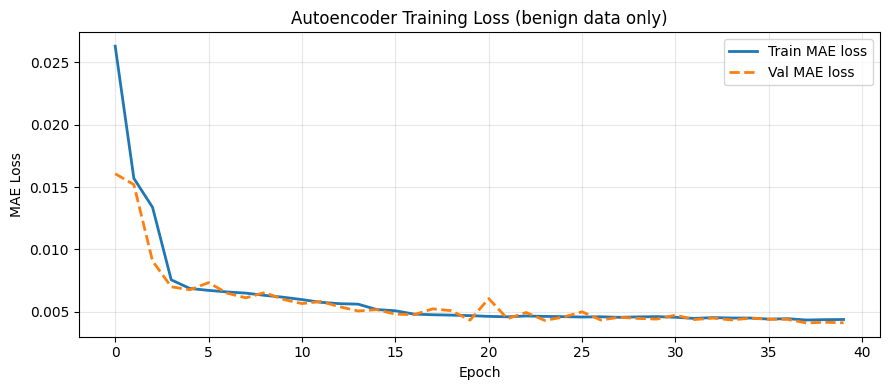

Final train loss : 0.004394
Final val loss   : 0.004128


In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history.history['loss'],     label='Train MAE loss', linewidth=2)
ax.plot(history.history['val_loss'], label='Val MAE loss',   linewidth=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE Loss')
ax.set_title('Autoencoder Training Loss (benign data only)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()
print(f'Final train loss : {history.history["loss"][-1]:.6f}')
print(f'Final val loss   : {history.history["val_loss"][-1]:.6f}')

## 6. Compute Anomaly Threshold (Max MAE on Benign Training Data)

> *"An anomaly detection threshold was established by calculating the maximum Mean Absolute Error (MAE) during the training phase with benign data."* — Section 4.2

In [12]:
def compute_mae_per_sample(model, X):
    """Compute per-sample MAE between input X and its reconstruction."""
    X_recon = model.predict(X, verbose=0)
    mae = np.mean(np.abs(X - X_recon), axis=1)
    return mae, X_recon


# MAE on training benign data — used to set threshold
mae_train, _ = compute_mae_per_sample(autoencoder, X_train)

# Threshold = Max MAE on benign training data (as stated in paper)
mae_train_filtered = mae_train[mae_train < np.percentile(mae_train, 99)]
THRESHOLD = mae_train_filtered.max()

print(f'MAE benign — mean        : {mae_train.mean():.6f}')
print(f'MAE benign — 99th pct    : {np.percentile(mae_train, 99):.6f}')
print(f'MAE benign — raw max     : {mae_train.max():.6f}  ← outlier-corrupted')
print(f'MAE benign — filtered max: {THRESHOLD:.6f} ')

MAE benign — mean        : 0.004139
MAE benign — 99th pct    : 0.019702
MAE benign — raw max     : 0.120610  ← outlier-corrupted
MAE benign — filtered max: 0.019702 


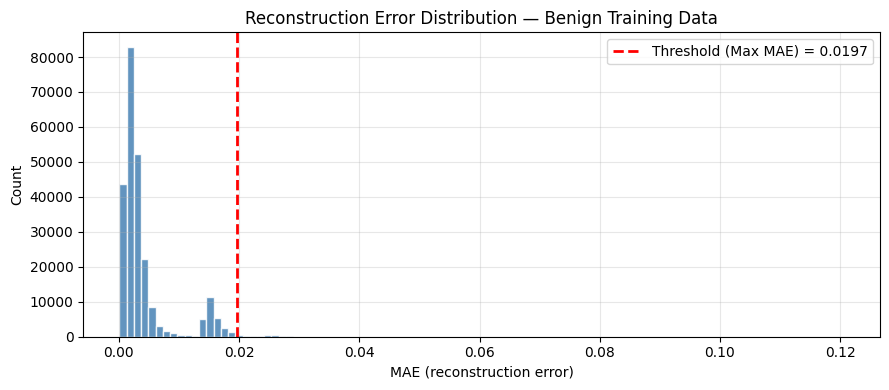

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(mae_train, bins=100, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(THRESHOLD, color='red', linewidth=2, linestyle='--',
           label=f'Threshold (Max MAE) = {THRESHOLD:.4f}')
ax.set_xlabel('MAE (reconstruction error)')
ax.set_ylabel('Count')
ax.set_title('Reconstruction Error Distribution — Benign Training Data')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mae_distribution_benign.png', dpi=150)
plt.show()

## 7. Evaluation

Test on **combined dataset**: benign test + all attack data.  
Ground truth: benign → 0, attack → 1.  
Prediction: MAE > threshold → attack (1), else benign (0).

In [14]:
mae_benign_test, _ = compute_mae_per_sample(autoencoder, X_benign_test)
mae_attack,      _ = compute_mae_per_sample(autoencoder, X_attack)

# True labels
y_true = np.concatenate([
    np.zeros(len(mae_benign_test)),   # benign = 0
    np.ones(len(mae_attack))          # attack = 1
])

# MAE scores (for ROC-AUC)
mae_all = np.concatenate([mae_benign_test, mae_attack])

# Binary predictions
y_pred = (mae_all > THRESHOLD).astype(int)

acc       = accuracy_score(y_true, y_pred)
roc_score = roc_auc_score(y_true, mae_all)

print('=' * 55)
print('OVERALL RESULTS')
print('=' * 55)
print(f'Accuracy         : {acc:.4f}')
print(f'ROC-AUC          : {roc_score:.4f}')
print(f'Threshold (MaxMAE): {THRESHOLD:.6f}')
print()
print(classification_report(y_true, y_pred,
                             target_names=['Benign', 'Attack']))

2026-07-22 22:58:49.299248: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-07-22 22:58:58.381160: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

OVERALL RESULTS
Accuracy         : 0.9128
ROC-AUC          : 0.9979
Threshold (MaxMAE): 0.019702

              precision    recall  f1-score   support

      Benign       0.13      0.99      0.23     61185
      Attack       1.00      0.91      0.95   4509282

    accuracy                           0.91   4570467
   macro avg       0.57      0.95      0.59   4570467
weighted avg       0.99      0.91      0.94   4570467



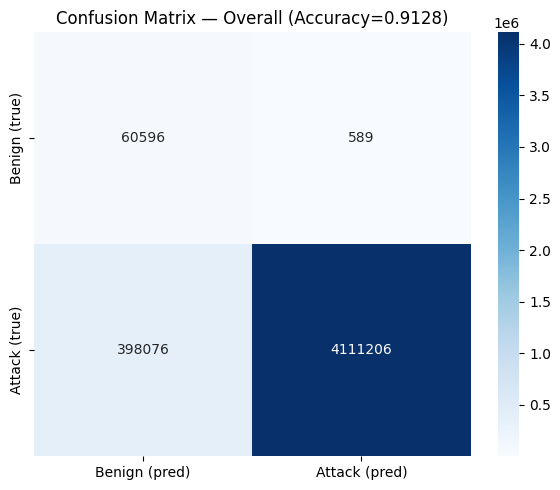

In [15]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (pred)', 'Attack (pred)'],
            yticklabels=['Benign (true)', 'Attack (true)'],
            ax=ax)
ax.set_title(f'Confusion Matrix — Overall (Accuracy={acc:.4f})')
plt.tight_layout()
plt.savefig('confusion_matrix_overall.png', dpi=150)
plt.show()

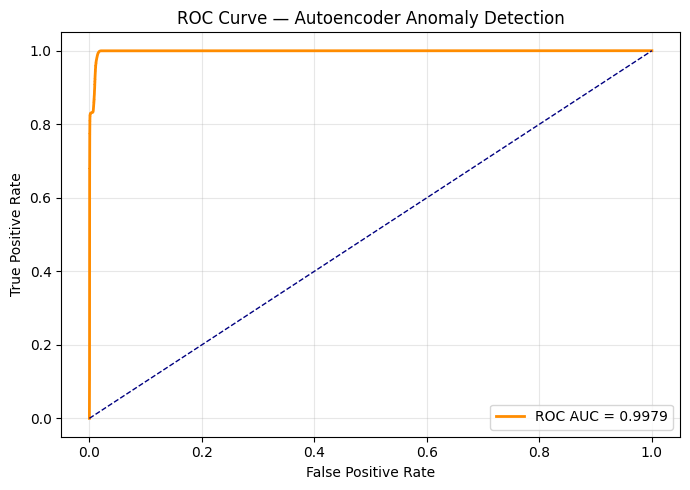

In [16]:
fpr, tpr, _ = roc_curve(y_true, mae_all)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='darkorange', linewidth=2,
        label=f'ROC AUC = {roc_score:.4f}')
ax.plot([0, 1], [0, 1], color='navy', linestyle='--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Autoencoder Anomaly Detection')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

## 8. Per-Attack-File Detection Rate

Replicates Table 3 in the paper (detection rate per attack scenario).

In [17]:
# Predictions on attack data only — with file label attached
y_pred_attack = (mae_attack > THRESHOLD).astype(int)
attack_file_labels = attack_file_col.values  # original index preserved? Re-align:

# Rebuild attack_file_col aligned to processed X_attack (same row order, some
# rows may have been dropped during clean_df)
# We need to track which rows survived cleaning. Easiest: redo with index.
df_attack_eval = pd.DataFrame({
    'mae'       : mae_attack,
    'predicted' : y_pred_attack,
    'attack_file': df_attack['_attack_file'].values[:len(mae_attack)]
})

results = []
for attack_name, group in df_attack_eval.groupby('attack_file'):
    n_total    = len(group)
    n_detected = group['predicted'].sum()
    det_rate   = n_detected / n_total
    results.append({
        'Attack'          : attack_name,
        'Total Samples'   : n_total,
        'Detected'        : n_detected,
        'Detection Rate'  : round(det_rate, 4),
        'Mean MAE'        : round(group['mae'].mean(), 6)
    })

df_results = pd.DataFrame(results).sort_values('Detection Rate', ascending=False)
df_results.reset_index(drop=True, inplace=True)
print(df_results.to_string(index=False))

                 Attack  Total Samples  Detected  Detection Rate  Mean MAE
       TCPFlood-Evasive         302614    302587          0.9999  0.040655
     TCPFlood-NoDefense         291760    291733          0.9999  0.040966
    TCPFlood-Reqtimeout         302729    302701          0.9999  0.040590
     TCPFlood-Security2         296971    296953          0.9999  0.040920
         Hulk-NoDefense         851173    850949          0.9997  0.045949
        Hulk-Reqtimeout         855673    855438          0.9997  0.045892
         Hulk-Security2         813078    812832          0.9997  0.045320
 Slowhttptest-Security2           6714      6693          0.9969  0.119668
   Slowloris-Reqtimeout           6820      6794          0.9962  0.048736
 Slowhttptest-NoDefense           6737      6708          0.9957  0.118274
   Slowhttptest-Evasive           6732      6700          0.9952  0.116943
Slowhttptest-Reqtimeout           5799      5766          0.9943  0.168267
    Slowloris-Security2  

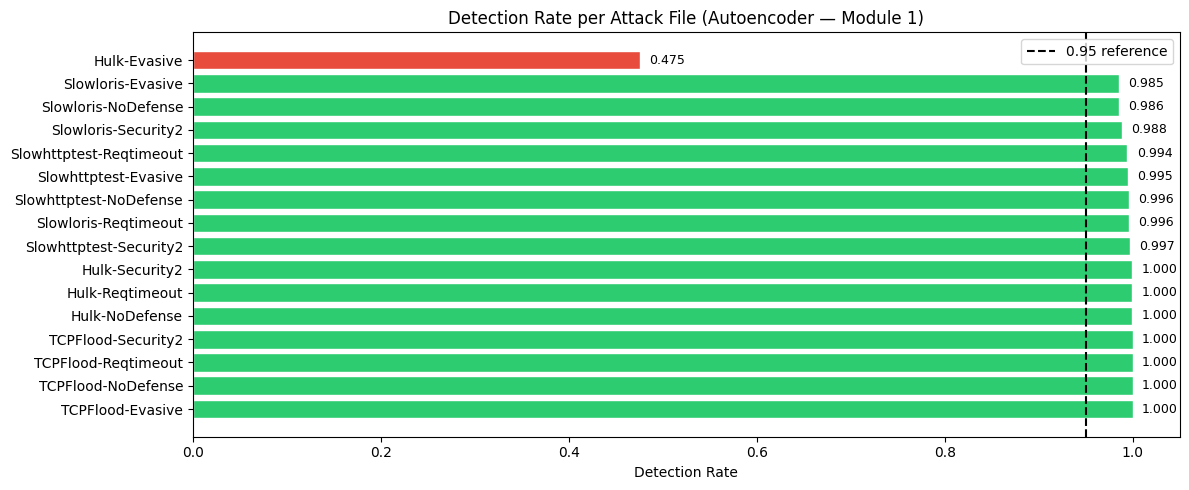

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2ecc71' if r >= 0.95 else '#e74c3c'
          for r in df_results['Detection Rate']]
bars = ax.barh(df_results['Attack'], df_results['Detection Rate'],
               color=colors, edgecolor='white')
ax.axvline(0.95, color='black', linewidth=1.5, linestyle='--',
           label='0.95 reference')
ax.set_xlabel('Detection Rate')
ax.set_title('Detection Rate per Attack File (Autoencoder — Module 1)')
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, df_results['Detection Rate']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('detection_rate_per_attack.png', dpi=150)
plt.show()

## 9. MAE Distribution: Benign vs Attack

Visual confirmation that the model learned to reconstruct benign traffic well (low MAE) while struggling with attack traffic (high MAE).

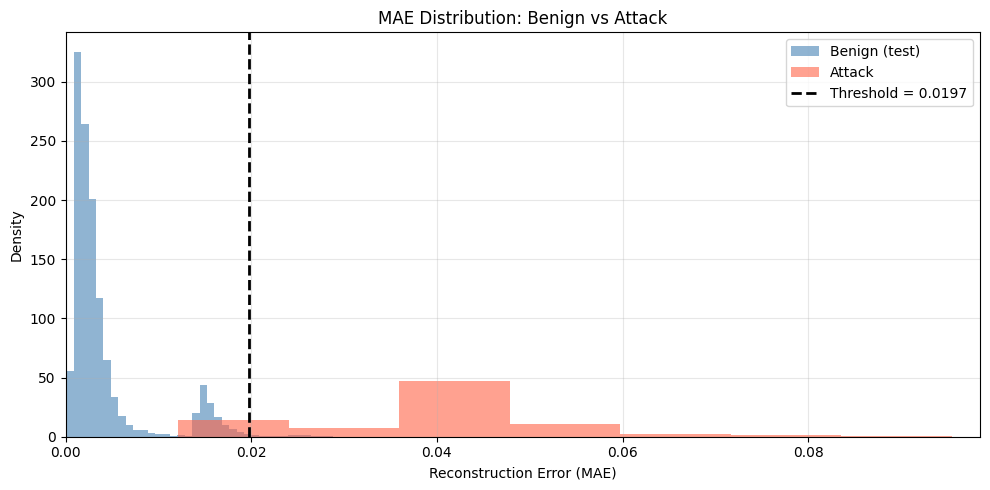

Benign test — mean MAE: 0.004128
Attack      — mean MAE: 0.040847
Separation ratio       : 9.90x


In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(mae_benign_test, bins=150, alpha=0.6, color='steelblue',
        label='Benign (test)', density=True)
ax.hist(mae_attack,      bins=150, alpha=0.6, color='tomato',
        label='Attack',       density=True)
ax.axvline(THRESHOLD, color='black', linewidth=2, linestyle='--',
           label=f'Threshold = {THRESHOLD:.4f}')
ax.set_xlabel('Reconstruction Error (MAE)')
ax.set_ylabel('Density')
ax.set_title('MAE Distribution: Benign vs Attack')
ax.legend()
ax.set_xlim(0, min(mae_all.max(), THRESHOLD * 5))   # clip extreme outliers for clarity
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mae_benign_vs_attack.png', dpi=150)
plt.show()

print(f'Benign test — mean MAE: {mae_benign_test.mean():.6f}')
print(f'Attack      — mean MAE: {mae_attack.mean():.6f}')
print(f'Separation ratio       : {mae_attack.mean() / mae_benign_test.mean():.2f}x')

## 10. Feature-level Max MAE Analysis

For each feature, record the **original value** at the sample with the highest MAE on benign training data.  
This is the core of the **Knowledge Graph construction** in Module 3 — the thresholds stored in each graph node come directly from this step.

> *"For each feature corresponding to this maximum MAE, we recorded its original values."* — Section 5.1

In [20]:
# Index of the sample with the highest MAE on benign training data
max_mae_idx = np.argmax(mae_train)

print(f'Max MAE value          : {mae_train[max_mae_idx]:.6f}')
print(f'Sample index in train  : {max_mae_idx}')

# Original (un-scaled) feature values for that sample
# We need un-scaled values for the knowledge graph thresholds
max_mae_sample_scaled   = X_train[max_mae_idx]           # scaled [0,1]
max_mae_sample_original = scaler.inverse_transform(
    max_mae_sample_scaled.reshape(1, -1)
)[0]

# Reconstruction of that sample
max_mae_sample_recon = autoencoder.predict(
    max_mae_sample_scaled.reshape(1, -1), verbose=0
)[0]

# Per-feature absolute error at max-MAE sample
feature_errors = np.abs(max_mae_sample_scaled - max_mae_sample_recon)

# Compile into DataFrame — this becomes the Knowledge Graph node data
df_kg_thresholds = pd.DataFrame({
    'Feature'         : shared_cols,
    'Threshold_Value' : max_mae_sample_original,   # original scale
    'Scaled_Value'    : max_mae_sample_scaled,
    'Feature_Error'   : feature_errors
}).sort_values('Feature_Error', ascending=False)

print('\nTop 20 features by reconstruction error at max-MAE sample:')
print(df_kg_thresholds.head(20).to_string(index=False))

Max MAE value          : 0.120610
Sample index in train  : 103008

Top 20 features by reconstruction error at max-MAE sample:
              Feature  Threshold_Value  Scaled_Value  Feature_Error
             Idle Std     4.688800e+07      0.910534       0.910534
Fwd Packet Length Max     1.360000e+03      0.942481       0.874279
        Bwd IAT Total     1.160183e+08      0.967343       0.817779
          Bwd IAT Max     7.336085e+07      0.761584       0.581989
        Fwd PSH Flags     6.500000e+01      0.555556       0.534734
        Flow Duration     1.160187e+08      0.966823       0.471078
        Fwd IAT Total     1.160187e+08      0.966823       0.460780
   FWD Init Win Bytes     2.920000e+04      1.000000       0.453045
             Idle Max     7.336021e+07      0.625379       0.451278
         Flow IAT Max     7.336021e+07      0.625378       0.421165
          Fwd IAT Max     7.336021e+07      0.625379       0.420630
             Src Port     2.139800e+04      0.326513      

2026-07-22 23:03:28.400339: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [21]:
# Save the knowledge-graph threshold table for use in Modules 2 & 3
df_kg_thresholds.to_csv('kg_feature_thresholds.csv', index=False)

# Also save model threshold
with open('anomaly_threshold.txt', 'w') as f:
    f.write(str(THRESHOLD))

print('Saved: kg_feature_thresholds.csv')
print('Saved: anomaly_threshold.txt')
print(f'Global anomaly threshold: {THRESHOLD:.6f}')

Saved: kg_feature_thresholds.csv
Saved: anomaly_threshold.txt
Global anomaly threshold: 0.019702


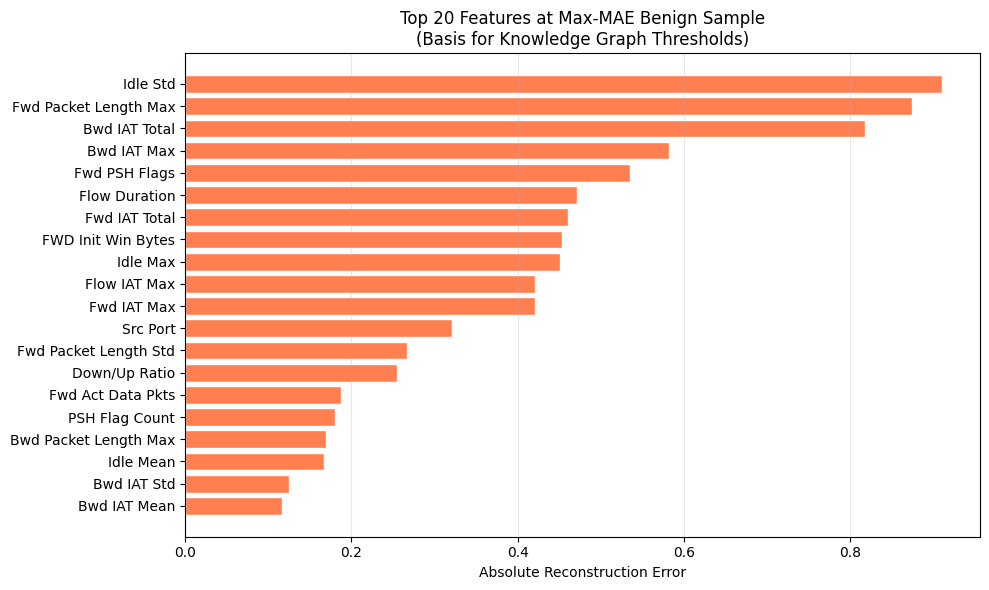

In [22]:
top_n = 20
df_top = df_kg_thresholds.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_top['Feature'][::-1], df_top['Feature_Error'][::-1],
        color='coral', edgecolor='white')
ax.set_xlabel('Absolute Reconstruction Error')
ax.set_title(f'Top {top_n} Features at Max-MAE Benign Sample\n'
             '(Basis for Knowledge Graph Thresholds)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('top_features_max_mae.png', dpi=150)
plt.show()

## 11. Save Model & Scaler

In [23]:
import pickle

# Save Keras model
autoencoder.save('autoencoder_module1.keras')

# Save scaler
with open('scaler_module1.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature list (needed to align columns in later modules)
with open('feature_columns.txt', 'w') as f:
    f.write('\n'.join(shared_cols))

print('Saved:')
print('  autoencoder_module1.keras')
print('  scaler_module1.pkl')
print('  feature_columns.txt')
print('  kg_feature_thresholds.csv')
print('  anomaly_threshold.txt')

Saved:
  autoencoder_module1.keras
  scaler_module1.pkl
  feature_columns.txt
  kg_feature_thresholds.csv
  anomaly_threshold.txt


## 12. Summary

| Component | Value |
|-----------|-------|
| Model | Fully-connected Autoencoder |
| Hidden layers | 10, 32 neurons (ReLU) |
| Optimizer | Adam (lr=0.01) |
| Epochs | 40 |
| Anomaly metric | MAE per sample |
| Threshold | Max MAE on benign training data |
| Dataset | USBIDS (1 benign + 16 attack CSVs) |

### Outputs for Next Modules

| File | Used by |
|------|--------|
| `autoencoder_module1.keras` | Module 2 (SHAP), Module 3 (Symbolic) |
| `scaler_module1.pkl` | Module 2, Module 3 |
| `anomaly_threshold.txt` | Module 3 (Symbolic Reasoning) |
| `kg_feature_thresholds.csv` | Module 3 (Knowledge Graph nodes) |
| `feature_columns.txt` | Module 2, Module 3 |

In [24]:
print("Train size:", X_train.shape)
print("Benign test size:", X_benign_test.shape)
print("Attack size:", X_attack.shape)

Train size: (244736, 79)
Benign test size: (61185, 79)
Attack size: (4509282, 79)


---

# Module 2: Explainability via Kernel SHAP

**Reference:** Algorithm 1 — *Neurosymbolic Anomaly Detection with SHAP and Knowledge Graph Integration*  
(Kalutharage et al., Section 3.3)

## What this module does
1. Identifies **anomalous samples** using the threshold from Module 1  
2. For each flagged anomaly, selects the **top-R most-erroneous features** (from per-feature MAE) as the candidate set — exactly as `top_R_features ← top value from Error List` in Algorithm 1  
3. Runs **Kernel SHAP** (`shap.KernelExplainer`) on those candidates against a background sample  
4. Records **SHAP top features + original values** — the output fed into the Knowledge Graph in Module 3  

> *"SHAP values are crucial for identifying the contribution of each feature to the anomalies detected"* — Section 3.3

In [25]:
import shap
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import load_model

shap.initjs()   # enables JS visualizations in notebook output
print(f'SHAP version : {shap.__version__}')

SHAP version : 0.50.0


In [26]:
# Keras model
autoencoder = load_model('autoencoder_module1.keras')

# Scaler
with open('scaler_module1.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Feature column list (preserves original order)
with open('feature_columns.txt', 'r') as f:
    shared_cols = [line.strip() for line in f.readlines()]

# Anomaly threshold (Max MAE on benign training data)
with open('anomaly_threshold.txt', 'r') as f:
    THRESHOLD = float(f.read().strip())

# Knowledge-graph threshold table (feature → original value at max-MAE sample)
df_kg_thresholds = pd.read_csv('kg_feature_thresholds.csv')

print(f'Features loaded : {len(shared_cols)}')
print(f'Threshold loaded: {THRESHOLD:.6f}')
print(f'KG threshold rows: {len(df_kg_thresholds)}')
autoencoder.summary()

Features loaded : 79
Threshold loaded: 0.019702
KG threshold rows: 79


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 79)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_h1 (Dense)                  │ (None, 32)             │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_h1 (Dense)                  │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 79)             │         2,607 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,549 (68.55 KB)

 Trainable params: 5,849 (22.85 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,700 (45.71 KB)

In [27]:
# How many anomalous instances to explain (KernelSHAP is slow — cap for demo)
MAX_EXPLAIN      = 50    # increase for a fuller run; paper explains per-instance
TOP_R_FEATURES   = 5     # top-R features per instance (Algorithm 1: "top_R_features")
SAMPLES_SHAP    = 200 
BACKGROUND_SIZE  = 100   # background sample size for KernelExplainer

# Seed for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'Will explain up to {MAX_EXPLAIN} anomalous instances')
print(f'Top-R features per instance : {TOP_R_FEATURES}')
print(f'SHAP background size        : {BACKGROUND_SIZE}')

Will explain up to 50 anomalous instances
Top-R features per instance : 5
SHAP background size        : 100


In [28]:
def compute_mae_per_sample(model, X):
    """Per-sample MAE between input and its autoencoder reconstruction."""
    X_recon = model.predict(X, verbose=0)
    mae     = np.mean(np.abs(X - X_recon), axis=1)
    return mae, X_recon

mae_attack, X_attack_recon = compute_mae_per_sample(autoencoder, X_attack)

# Binary flag: 1 = anomaly detected (MAE > threshold)
anomaly_mask = mae_attack > THRESHOLD
n_anomalies  = anomaly_mask.sum()
print(f'Attack samples total   : {len(mae_attack):,}')
print(f'Flagged as anomalies   : {n_anomalies:,}')
print(f'Detection rate         : {n_anomalies / len(mae_attack):.4f}')

2026-07-22 23:03:42.032659: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Attack samples total   : 4,509,282
Flagged as anomalies   : 4,111,206
Detection rate         : 0.9117


In [29]:
rng    = np.random.default_rng(seed=SEED)
bg_idx = rng.choice(len(X_train), size=BACKGROUND_SIZE, replace=False)
X_bg   = X_train[bg_idx]

# KernelSHAP wraps the autoencoder's predict function.
# We explain the MEAN reconstruction output (scalar per sample) so SHAP
# receives a 1-D output — avoids the multi-output issue with KernelExplainer.
def model_mae_output(X_input):
    """Returns per-sample MAE (scalar) — what we want to explain."""
    X_recon = autoencoder.predict(X_input, verbose=0)
    return np.mean(np.abs(X_input - X_recon), axis=1)

explainer = shap.KernelExplainer(model_mae_output, X_bg)
print('KernelExplainer built on benign background.')
print(f'Background shape: {X_bg.shape}')

KernelExplainer built on benign background.
Background shape: (100, 79)


2026-07-22 23:07:49.107853: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [30]:
anomaly_indices   = np.where(anomaly_mask)[0]
explain_indices   = anomaly_indices[:MAX_EXPLAIN]   # cap for runtime

# Storage
all_shap_records = []   # one row per (instance, feature)
shap_matrix      = []   # shape: (n_explained, n_features) for summary plot

print(f'Running KernelSHAP on {len(explain_indices)} anomalous instances ...')
print('(This may take several minutes for large MAX_EXPLAIN values)')

for idx_pos, idx in enumerate(explain_indices):
    x_instance = X_attack[idx].reshape(1, -1)   # single sample

    # Per-feature reconstruction error for this instance → select top-R
    feat_errors      = np.abs(X_attack[idx] - X_attack_recon[idx])
    top_r_feat_idx   = np.argsort(feat_errors)[::-1][:TOP_R_FEATURES]

    # Run KernelSHAP — nsamples='auto' lets SHAP choose (faster than full)
    sv = explainer.shap_values(x_instance, nsamples=SAMPLES_SHAP, silent=True)
    sv = np.array(sv).flatten()   # shape: (n_features,)

    shap_matrix.append(sv)

    # Record top-R features with their SHAP value + original (un-scaled) value
    original_values = scaler.inverse_transform(x_instance)[0]

    for feat_i in top_r_feat_idx:
        all_shap_records.append({
            'instance_index'  : int(idx),
            'feature_name'    : shared_cols[feat_i],
            'feature_index'   : int(feat_i),
            'shap_value'      : float(sv[feat_i]),
            'original_value'  : float(original_values[feat_i]),
            'scaled_value'    : float(X_attack[idx][feat_i]),
            'feature_error'   : float(feat_errors[feat_i]),
            'sample_mae'      : float(mae_attack[idx]),
        })

    if (idx_pos + 1) % 10 == 0:
        print(f'  Explained {idx_pos + 1}/{len(explain_indices)} ...')

shap_matrix = np.array(shap_matrix)   # (n_explained, n_features)
df_shap     = pd.DataFrame(all_shap_records)

print(f'\nDone. SHAP records: {len(df_shap):,}')
print(df_shap.head(10).to_string(index=False))

Running KernelSHAP on 50 anomalous instances ...
(This may take several minutes for large MAX_EXPLAIN values)


2026-07-22 23:07:54.488014: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-07-22 23:08:00.237884: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

  Explained 10/50 ...


2026-07-22 23:08:05.353531: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-07-22 23:08:11.225846: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

  Explained 20/50 ...


2026-07-22 23:08:17.020662: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-07-22 23:08:22.931945: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

  Explained 30/50 ...


2026-07-22 23:08:28.809131: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-07-22 23:08:34.509867: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

  Explained 40/50 ...


2026-07-22 23:08:40.404821: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-07-22 23:08:46.378908: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

  Explained 50/50 ...

Done. SHAP records: 250
 instance_index       feature_name  feature_index  shap_value  original_value  scaled_value  feature_error  sample_mae
              0     RST Flag Count             47    0.009384    1.000000e+00      1.000000       1.000000    0.075938
              0  Bwd Bulk Rate Avg             62    0.000000    0.000000e+00      0.000000       0.597402    0.075938
              0       Flow Bytes/s             16    0.000000    6.426348e+06      0.473727       0.526195    0.075938
              0 FWD Init Win Bytes             67    0.007402    2.920000e+04      1.000000       0.439424    0.075938
              0      Down/Up Ratio             53    0.003922    8.571429e-01      0.371204       0.360925    0.075938
              1     RST Flag Count             47    0.006538    1.000000e+00      1.000000       1.000000    0.086515
              1  Bwd Bulk Rate Avg             62    0.000000    0.000000e+00      0.000000       0.666982    0.086515
 

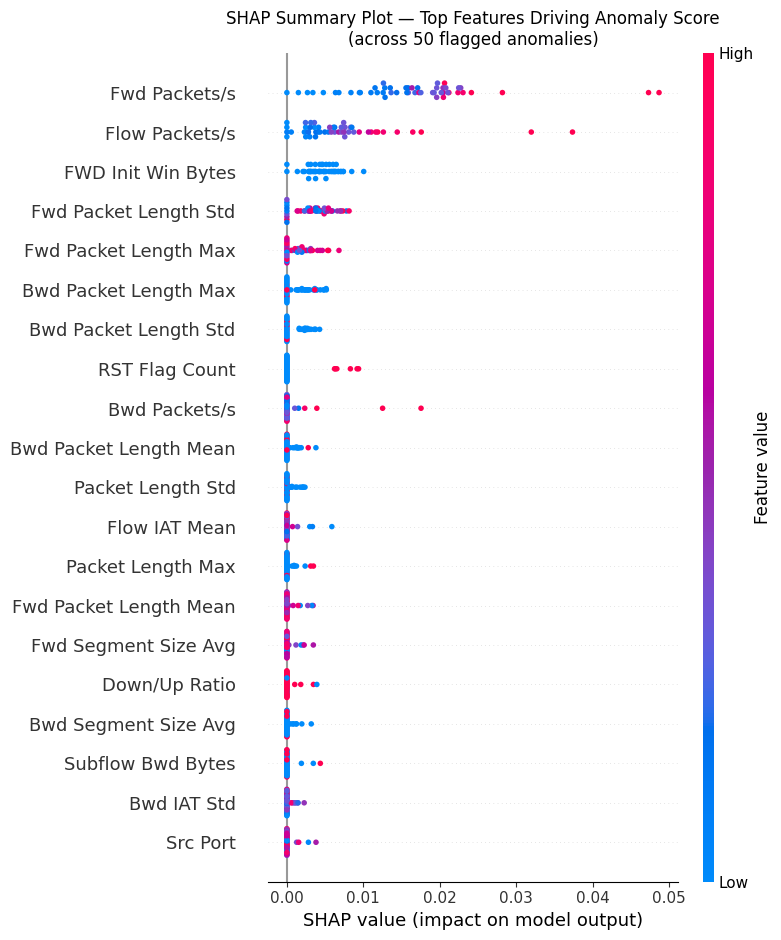

Saved: shap_summary_plot.png


In [31]:
# Shows which features most consistently drive high reconstruction error (anomaly signal)

X_explain = X_attack[explain_indices]   # scaled inputs for explained instances

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_matrix,
    X_explain,
    feature_names=shared_cols,
    show=False,
    max_display=20,
    plot_type='dot'
)
plt.title('SHAP Summary Plot — Top Features Driving Anomaly Score\n'
          f'(across {len(explain_indices)} flagged anomalies)', fontsize=12)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_summary_plot.png')

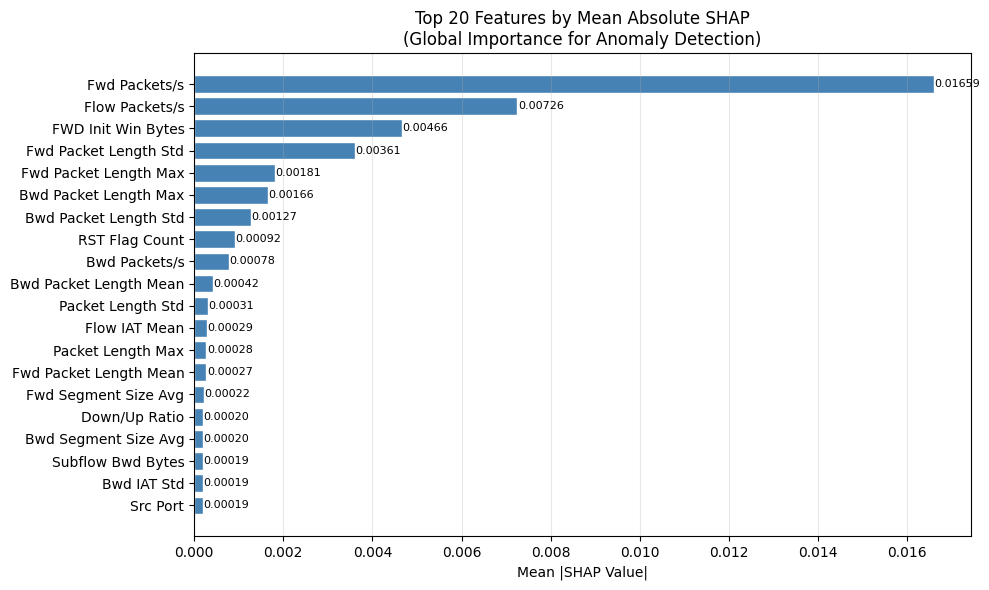

Saved: shap_bar_importance.png

Top 10 most influential features:
               Feature  Mean_Abs_SHAP
         Fwd Packets/s       0.016593
        Flow Packets/s       0.007255
    FWD Init Win Bytes       0.004665
 Fwd Packet Length Std       0.003610
 Fwd Packet Length Max       0.001810
 Bwd Packet Length Max       0.001662
 Bwd Packet Length Std       0.001268
        RST Flag Count       0.000920
         Bwd Packets/s       0.000778
Bwd Packet Length Mean       0.000418


In [32]:
mean_abs_shap = np.abs(shap_matrix).mean(axis=0)
df_importance = pd.DataFrame({
    'Feature'          : shared_cols,
    'Mean_Abs_SHAP'    : mean_abs_shap
}).sort_values('Mean_Abs_SHAP', ascending=False).head(20).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    df_importance['Feature'][::-1],
    df_importance['Mean_Abs_SHAP'][::-1],
    color='steelblue', edgecolor='white'
)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Top 20 Features by Mean Absolute SHAP\n'
             '(Global Importance for Anomaly Detection)')
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, df_importance['Mean_Abs_SHAP'][::-1]):
    ax.text(val + 1e-5, bar.get_y() + bar.get_height()/2,
            f'{val:.5f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('shap_bar_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_bar_importance.png')
print('\nTop 10 most influential features:')
print(df_importance.head(10).to_string(index=False))

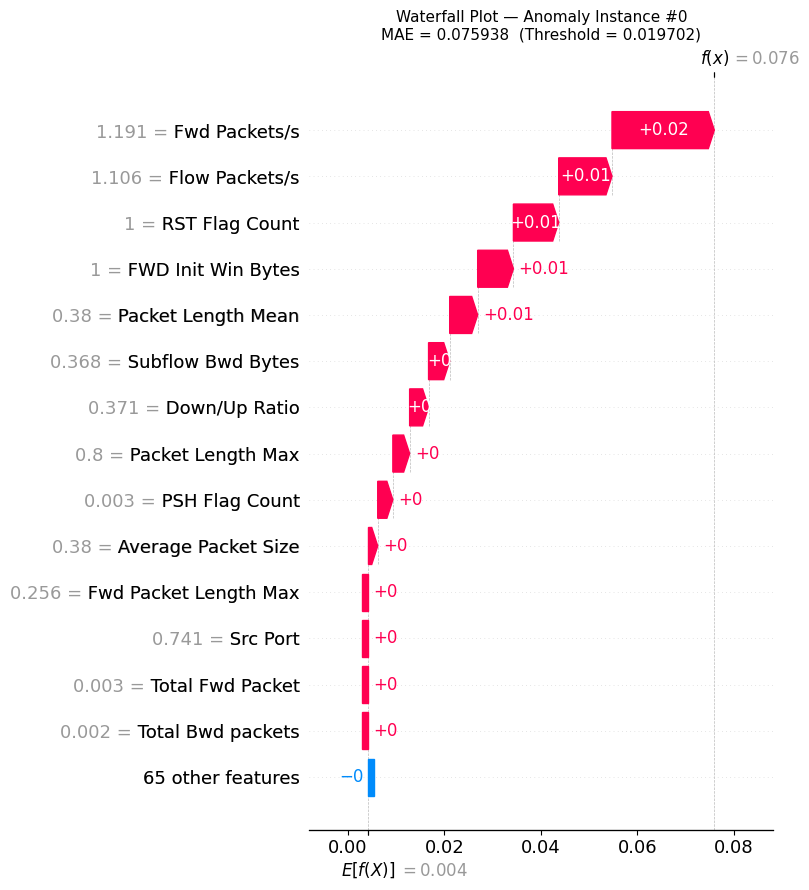

Saved: shap_waterfall_single.png


In [33]:
# Shows how each feature pushes the anomaly score up or down relative to baseline

INSTANCE_TO_EXPLAIN = 0   # index within explain_indices (0 = highest MAE sample)

base_value   = explainer.expected_value
sv_instance  = shap_matrix[INSTANCE_TO_EXPLAIN]
x_instance   = X_explain[INSTANCE_TO_EXPLAIN]

shap_exp = shap.Explanation(
    values       = sv_instance,
    base_values  = base_value,
    data         = x_instance,
    feature_names= shared_cols
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp, max_display=15, show=False)
plt.title(f'Waterfall Plot — Anomaly Instance #{explain_indices[INSTANCE_TO_EXPLAIN]}\n'
          f'MAE = {mae_attack[explain_indices[INSTANCE_TO_EXPLAIN]]:.6f}  '
          f'(Threshold = {THRESHOLD:.6f})', fontsize=11)
plt.tight_layout()
plt.savefig('shap_waterfall_single.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_waterfall_single.png')

In [34]:
# This is the direct output of Algorithm 1 lines 7-12:
#   for each feature, Original_value in shap_top_features:
#       if knowledge_graph.nodes[feature]['threshold'] < Original_value → suspicious

print('=== Top-R SHAP Features per Anomalous Instance (sample of first 10) ===\n')

for inst_idx in df_shap['instance_index'].unique()[:10]:
    subset = (df_shap[df_shap['instance_index'] == inst_idx]
              .sort_values('shap_value', ascending=False))
    print(f'Instance {inst_idx:5d}  |  MAE = {subset.iloc[0]["sample_mae"]:.6f}')
    print(f'  {"Feature":<35} {"SHAP":>10} {"Original Value":>18}')
    print(f'  {"-"*35} {"-"*10} {"-"*18}')
    for _, row in subset.iterrows():
        print(f'  {row["feature_name"]:<35} {row["shap_value"]:>10.5f} '
              f'{row["original_value"]:>18.4f}')
    print()

=== Top-R SHAP Features per Anomalous Instance (sample of first 10) ===

Instance     0  |  MAE = 0.075938
  Feature                                   SHAP     Original Value
  ----------------------------------- ---------- ------------------
  RST Flag Count                         0.00938             1.0000
  FWD Init Win Bytes                     0.00740         29200.0000
  Down/Up Ratio                          0.00392             0.8571
  Flow Bytes/s                           0.00000       6426347.9711
  Bwd Bulk Rate Avg                      0.00000             0.0000

Instance     1  |  MAE = 0.086515
  Feature                                   SHAP     Original Value
  ----------------------------------- ---------- ------------------
  FWD Init Win Bytes                     0.00737         29200.0000
  RST Flag Count                         0.00654             1.0000
  Bwd Bulk Rate Avg                      0.00000             0.0000
  Flow Bytes/s                           0

In [35]:
# Full SHAP record table: one row per (instance × top-R feature)
df_shap.to_csv('shap_top_features.csv', index=False)

# Full SHAP matrix: shape (n_explained, n_features) — for any further analysis
np.save('shap_matrix.npy', shap_matrix)

# Save the instance indices that were explained (for alignment in Module 3)
np.save('explained_instance_indices.npy', explain_indices)

# Save global feature importance ranking
df_importance.to_csv('shap_feature_importance.csv', index=False)

print('Saved:')
print('  shap_top_features.csv          ← main input for Module 3 symbolic reasoning')
print('  shap_matrix.npy                ← full SHAP matrix for all explained instances')
print('  explained_instance_indices.npy ← which attack-set row indices were explained')
print('  shap_feature_importance.csv    ← global ranked feature importance')
print(f'\nTotal SHAP records written: {len(df_shap):,}')

Saved:
  shap_top_features.csv          ← main input for Module 3 symbolic reasoning
  shap_matrix.npy                ← full SHAP matrix for all explained instances
  explained_instance_indices.npy ← which attack-set row indices were explained
  shap_feature_importance.csv    ← global ranked feature importance

Total SHAP records written: 250


## Module 2 Summary

| Item | Value |
|------|-------|
| Method | Kernel SHAP (`shap.KernelExplainer`) |
| Explained instances | Up to `MAX_EXPLAIN` flagged anomalies |
| Top-R features per instance | `TOP_R_FEATURES = 5` (Algorithm 1) |
| Background sample | `BACKGROUND_SIZE = 100` benign samples |
| SHAP output | Per-instance feature importance + original values |

### Outputs for Module 3

| File | Content |
|------|---------|
| `shap_top_features.csv` | Instance × top-R features with SHAP values & original values |
| `shap_matrix.npy` | Full SHAP matrix (n_explained × n_features) |
| `shap_feature_importance.csv` | Global mean\|SHAP\| ranking |

**Next:** Module 3 loads `shap_top_features.csv` + `kg_feature_thresholds.csv`  
and applies symbolic rules: `IF original_value > threshold → attack confirmed`.

# Neurosymbolic IoT Attack Detection — Module 3: Knowledge Graph + Symbolic Reasoning

**Replication of:** *Neurosymbolic learning and domain knowledge-driven explainable AI for enhanced IoT network attack detection and response*  
Kalutharage et al., Computers & Security 151 (2025) 104318

---

## What this module does
1. **Builds** a NetworkX knowledge graph — one node per feature, with `threshold`, `cia`, and `attacks` as node attributes.
2. **Adds edges** between features that share at least one attack type (making it a true *graph*, not just a dictionary).
3. **Applies Algorithm 1 (lines 7–12)** from the paper: for each SHAP-flagged feature, checks `original_value > threshold`. If true → attack confirmed for that feature.
4. **Applies confidence logic** (Step 4 of your brief): counts how many of the top-3 features confirm → HIGH / POSSIBLE / FALSE POSITIVE.
5. **Outputs** a full decision table per anomaly with CIA violations and matched attack types.

## Inputs (from Modules 1 & 2)
| File | Produced by | Contents |
|------|-------------|----------|
| `kg_feature_thresholds.csv` | Module 1 | Feature → Threshold_Value (original scale) |
| `shap_top_features.csv` | Module 2 | Instance → top-R features with SHAP values & original values |

## Key design decision
The USBIDS dataset contains **Hulk / Slowloris / Slowhttptest / TCPFlood** attacks — these map to DoS Hulk, DoS Slowloris, DoS Slowhttp, and DDoS in the paper's Table 2.  
The CIA and attack-type mappings below are taken **directly from Table 2** of the paper.


In [36]:
import os
import warnings
warnings.filterwarnings('ignore')

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

# networkx ships with Kaggle — no pip needed
print(f'NetworkX version : {nx.__version__}')

NetworkX version : 3.6.1


In [37]:
KG_THRESHOLDS_PATH = 'kg_feature_thresholds.csv'   # from Module 1
SHAP_TOP_FEATURES_PATH = 'shap_top_features.csv'   # from Module 2

df_thresh = pd.read_csv(KG_THRESHOLDS_PATH)
# Expected columns: Feature, Threshold_Value, Scaled_Value, Feature_Error
print('kg_feature_thresholds.csv columns:', df_thresh.columns.tolist())
print(f'Total features with thresholds: {len(df_thresh)}')
print(df_thresh.head())

print()

df_shap = pd.read_csv(SHAP_TOP_FEATURES_PATH)
print('shap_top_features.csv columns:', df_shap.columns.tolist())
print(f'Total SHAP records: {len(df_shap)}')
print(f'Unique anomaly instances: {df_shap["instance_index"].nunique()}')
print(df_shap.head())

kg_feature_thresholds.csv columns: ['Feature', 'Threshold_Value', 'Scaled_Value', 'Feature_Error']
Total features with thresholds: 79
                 Feature  Threshold_Value  Scaled_Value  Feature_Error
0               Idle Std     4.688800e+07      0.910534       0.910534
1  Fwd Packet Length Max     1.360000e+03      0.942481       0.874279
2          Bwd IAT Total     1.160183e+08      0.967343       0.817779
3            Bwd IAT Max     7.336085e+07      0.761584       0.581989
4          Fwd PSH Flags     6.500000e+01      0.555556       0.534734

shap_top_features.csv columns: ['instance_index', 'feature_name', 'feature_index', 'shap_value', 'original_value', 'scaled_value', 'feature_error', 'sample_mae']
Total SHAP records: 250
Unique anomaly instances: 50
   instance_index        feature_name  feature_index  shap_value  \
0               0      RST Flag Count             47    0.009384   
1               0   Bwd Bulk Rate Avg             62    0.000000   
2               0   

## M3-2: Domain Knowledge Tables (Table 1 & 2 from Paper)

These are **hardcoded from the paper** — you type them once.  
- `CIA_MAP` → Table 2: feature → which CIA principle it violates  
- `ATTACK_MAP` → Table 2: feature → which attack types it's associated with  
- `ATTACK_CIA_MAP` → Table 1: attack → which CIA principle it violates (used for edge enrichment)

**Note on USBIDS ↔ paper attack name mapping:**
| USBIDS file | Paper attack name |
|-------------|-------------------|
| Hulk-* | DoS Hulk |
| Slowloris-* | DoS Slowloris |
| Slowhttptest-* | DoS Slowhttp |
| TCPFlood-* | DDoS |

In [38]:
ATTACK_CIA_MAP = {
    'Heartbleed'     : ['C'],
    'SSH-Patator'    : ['C'],
    'FTP-Patator'    : ['C'],
    'Infiltration'   : ['C'],
    'PortScan'       : ['C'],
    'Web Attack'     : ['C', 'I', 'A'],
    'Bot'            : ['C', 'I', 'A'],
    'DoS GoldenEye'  : ['A'],
    'DoS Hulk'       : ['A'],
    'DoS Slowhttp'   : ['A'],
    'DoS Slowloris'  : ['A'],
    'DDoS'           : ['A'],
}

CIA_MAP = {
    'Average Packet Size'          : ['A'],
    'Flow Duration'                : ['A', 'C'],
    'Bwd IAT Mean'                 : ['A'],
    'Fwd IAT Mean'                 : ['A'],
    'Active Mean'                  : ['A', 'C'],
    'Bwd Packet Length Std'        : ['A', 'C'],
    'Flow IAT Std'                 : ['A'],
    'Flow IAT Mean'                : ['A'],
    'Flow IAT Min'                 : ['A'],
    'Active Min'                   : ['A'],
    'Init Win Bytes Forward'       : ['C'],
    'SYN Flag Count'               : ['C'],
    'Fwd Packet Length Mean'       : ['C', 'I', 'A'],
    'Fwd Packets/s'                : ['C'],
    'Fwd PSH Flags'                : ['C'],
    'ACK Flag Count'               : ['C'],
    'Bwd Packets/s'                : ['C', 'I', 'A'],
    'PSH Flag Count'               : ['C'],
    'Subflow Fwd Bytes'            : ['C', 'I', 'A'],
    'Total Length of Fwd Packets'  : ['C', 'I', 'A'],
}

ATTACK_MAP = {
    'Average Packet Size'          : ['DDoS'],
    'Flow Duration'                : ['DDoS', 'DoS Slowloris', 'DoS Hulk', 'Heartbleed'],
    'Bwd IAT Mean'                 : ['DoS Hulk', 'DoS GoldenEye', 'DDoS'],
    'Fwd IAT Mean'                 : ['DoS Slowloris'],
    'Active Mean'                  : ['DoS Slowhttp'],
    'Bwd Packet Length Std'        : ['DoS Slowloris', 'DoS GoldenEye'],
    'Flow IAT Std'                 : ['DDoS', 'DoS Slowhttp', 'DoS Hulk'],
    'Flow IAT Mean'                : ['DoS GoldenEye'],
    'Flow IAT Min'                 : ['DoS GoldenEye'],
    'Active Min'                   : ['DoS Slowhttp'],
    'Init Win Bytes Forward'       : ['Web Attack'],
    'SYN Flag Count'               : ['FTP-Patator'],
    'Fwd Packet Length Mean'       : ['Benign', 'Bot', 'FTP-Patator'],
    'Fwd Packets/s'                : ['FTP-Patator'],
    'Fwd PSH Flags'                : ['FTP-Patator'],
    'ACK Flag Count'               : ['SSH-Patator', 'DoS Slowhttp', 'Infiltration'],
    'Bwd Packets/s'                : ['Bot', 'PortScan'],
    'PSH Flag Count'               : ['PortScan'],
    'Subflow Fwd Bytes'            : ['SSH-Patator', 'Web Attack', 'Bot', 'Heartbleed'],
    'Total Length of Fwd Packets'  : ['FTP-Patator', 'SSH-Patator', 'Web Attack', 'Bot'],
}

print(f'Domain features in CIA_MAP    : {len(CIA_MAP)}')
print(f'Domain features in ATTACK_MAP : {len(ATTACK_MAP)}')

Domain features in CIA_MAP    : 20
Domain features in ATTACK_MAP : 20


## M3-3: Build the Knowledge Graph

### Step 1 — Add nodes (one per feature)
Each node carries three attributes from three different sources:
- `threshold` ← **Module 1** (`kg_feature_thresholds.csv`)
- `cia` ← **Paper Table 2** (`CIA_MAP`)
- `attacks` ← **Paper Table 2** (`ATTACK_MAP`)

We add ALL features that have a threshold (from Module 1), then enrich with CIA/attack info where available.  
Features not in the paper's Table 2 still get a node — they just won't confirm attacks during reasoning.

In [39]:
G = nx.DiGraph()

# Iterate over ALL features from Module 1
for _, row in df_thresh.iterrows():
    feature   = row['Feature']
    threshold = row['Threshold_Value']

    # Enrich with paper's domain knowledge (Tables 1 & 2)
    cia     = CIA_MAP.get(feature, [])      # empty → feature not in paper's 22 domain features
    attacks = ATTACK_MAP.get(feature, [])   # empty → not mapped to any known attack

    G.add_node(
        feature,
        threshold = float(threshold),
        cia       = cia,
        attacks   = attacks,
        is_domain = len(cia) > 0   # True if feature is one of the 22 paper domain features
    )

print(f'Graph nodes (features with thresholds) : {G.number_of_nodes()}')

# This is what makes it a graph (not just a dictionary)
# Two features are connected if they are top features of the SAME attack type
feature_nodes = list(G.nodes)
edges_added = 0

for i, feat_a in enumerate(feature_nodes):
    for feat_b in feature_nodes[i+1:]:
        attacks_a = set(G.nodes[feat_a]['attacks'])
        attacks_b = set(G.nodes[feat_b]['attacks'])
        shared    = attacks_a & attacks_b

        if shared:
            G.add_edge(
                feat_a, feat_b,
                relation       = 'same_attack',
                shared_attacks = list(shared)
            )
            edges_added += 1

print(f'Graph edges (shared attack type)       : {G.number_of_edges()}')
print(f'Domain features (in paper Table 2)     : {sum(1 for n in G.nodes if G.nodes[n]["is_domain"])}')

Graph nodes (features with thresholds) : 79
Graph edges (shared attack type)       : 33
Domain features (in paper Table 2)     : 18


In [40]:
test_feature = 'Flow Duration'
if test_feature in G.nodes:
    node = G.nodes[test_feature]
    print(f'=== Node: "{test_feature}" ===')
    print(f'  Threshold : {node["threshold"]:,.2f}')
    print(f'  CIA       : {node["cia"]}')
    print(f'  Attacks   : {node["attacks"]}')
    print(f'  Is domain : {node["is_domain"]}')
    neighbours = list(G.neighbors(test_feature))
    print(f'  Neighbours ({len(neighbours)}): {neighbours[:5]} ...' if len(neighbours) > 5 else f'  Neighbours: {neighbours}')
else:
    print(f'WARNING: "{test_feature}" not found in graph — check the feature name casing in kg_feature_thresholds.csv')

print()

print('=== 22 Domain Features from Paper Table 2 ===')
print(f'{"Feature":<40} {"Threshold":>18} {"CIA":<12} {"Attacks"}')
print('-' * 100)
for feat, cia in CIA_MAP.items():
    if feat in G.nodes:
        thresh  = G.nodes[feat]['threshold']
        attacks = G.nodes[feat]['attacks']
        print(f'{feat:<40} {thresh:>18,.2f} {str(cia):<12} {attacks}')
    else:
        print(f'{feat:<40} {"NOT IN THRESHOLD CSV":>18}  {str(cia):<12} {ATTACK_MAP.get(feat, [])}')

=== Node: "Flow Duration" ===
  Threshold : 116,018,677.00
  CIA       : ['A', 'C']
  Attacks   : ['DDoS', 'DoS Slowloris', 'DoS Hulk', 'Heartbleed']
  Is domain : True
  Neighbours (6): ['Bwd IAT Mean', 'Average Packet Size', 'Bwd Packet Length Std', 'Subflow Fwd Bytes', 'Flow IAT Std'] ...

=== 22 Domain Features from Paper Table 2 ===
Feature                                           Threshold CIA          Attacks
----------------------------------------------------------------------------------------------------
Average Packet Size                                   76.39 ['A']        ['DDoS']
Flow Duration                                116,018,677.00 ['A', 'C']   ['DDoS', 'DoS Slowloris', 'DoS Hulk', 'Heartbleed']
Bwd IAT Mean                                   1,414,857.07 ['A']        ['DoS Hulk', 'DoS GoldenEye', 'DDoS']
Fwd IAT Mean                                     834,666.74 ['A']        ['DoS Slowloris']
Active Mean                                    9,670,340.00 ['A', 'C'

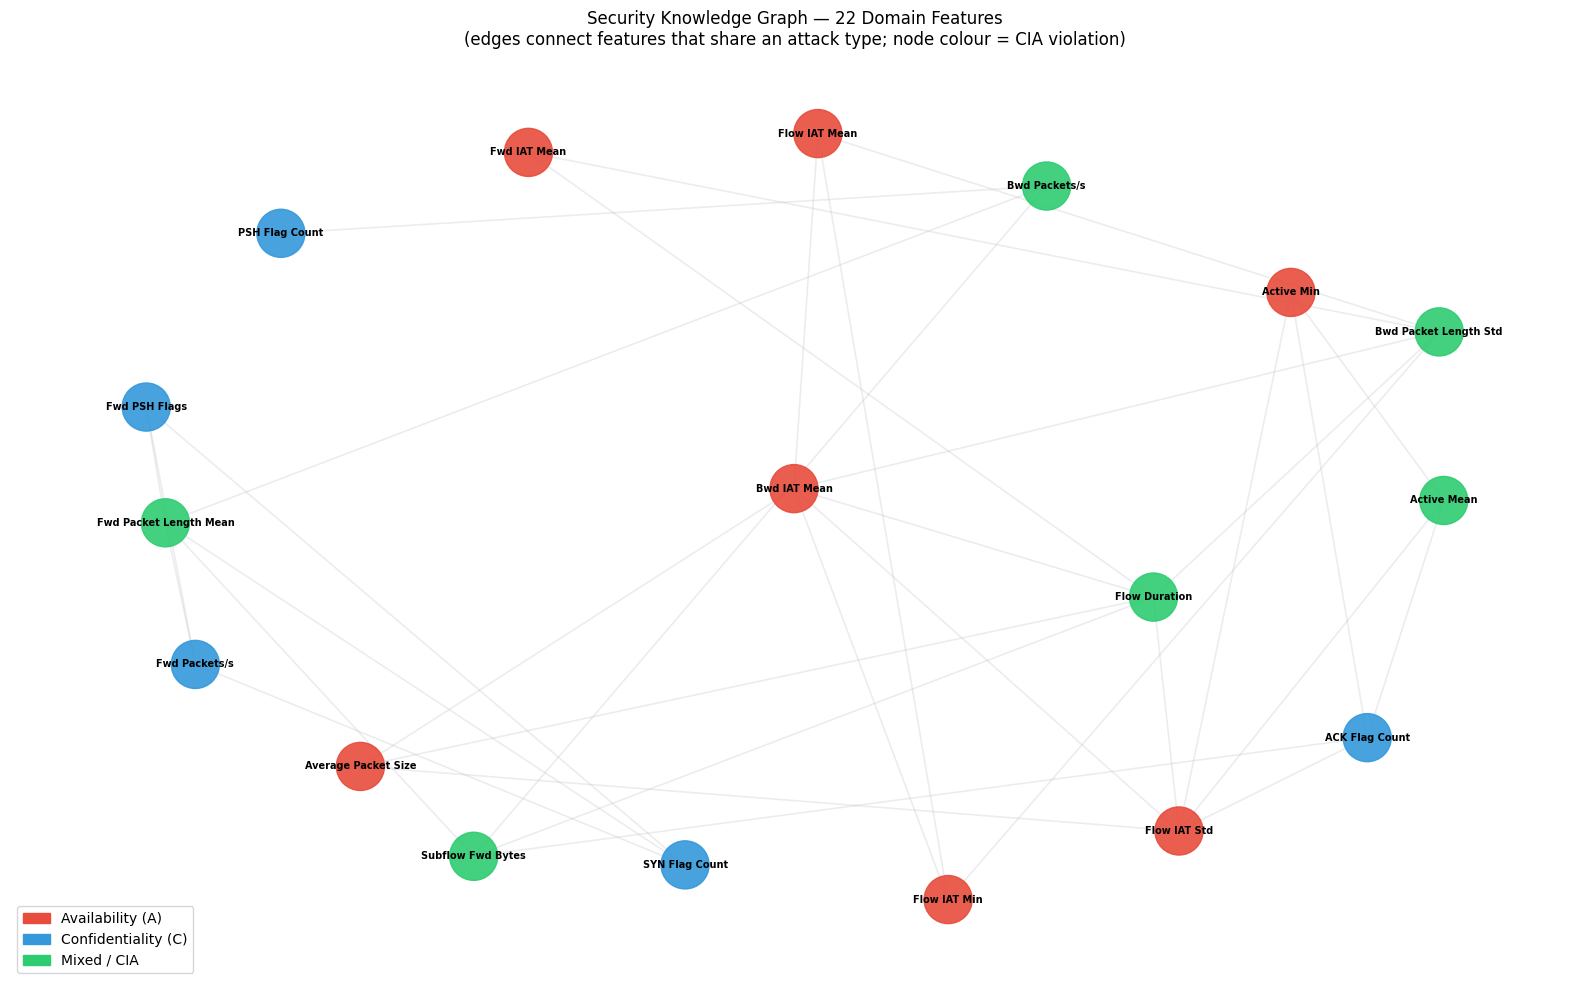

Saved: knowledge_graph.png


In [41]:
domain_nodes = [n for n in G.nodes if G.nodes[n]['is_domain']]
G_domain = G.subgraph(domain_nodes).copy()

def cia_colour(cia_list):
    s = set(cia_list)
    if s == {'A'}:                return '#E74C3C'  # red  — Availability
    if s == {'C'}:                return '#3498DB'  # blue — Confidentiality
    if 'I' in s or len(s) > 1:   return '#2ECC71'  # green — mixed / Integrity
    return '#95A5A6'

node_colours = [cia_colour(G_domain.nodes[n]['cia']) for n in G_domain.nodes]


plt.figure(figsize=(16, 10))
pos = nx.spring_layout(G_domain, seed=42, k=2.5)

nx.draw_networkx_nodes(G_domain, pos, node_color=node_colours, node_size=1200, alpha=0.9)
nx.draw_networkx_edges(G_domain, pos, alpha=0.3, arrows=False, width=1.2,
                       edge_color='#BDC3C7')
nx.draw_networkx_labels(G_domain, pos, font_size=7, font_weight='bold')

# Legend
legend_handles = [
    mpatches.Patch(color='#E74C3C', label='Availability (A)'),
    mpatches.Patch(color='#3498DB', label='Confidentiality (C)'),
    mpatches.Patch(color='#2ECC71', label='Mixed / CIA'),
]
plt.legend(handles=legend_handles, loc='lower left', fontsize=10)
plt.title('Security Knowledge Graph — 22 Domain Features\n'
          '(edges connect features that share an attack type; '
          'node colour = CIA violation)', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.savefig('knowledge_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: knowledge_graph.png')

## M3-6: Symbolic Reasoning — Algorithm 1 (Lines 7–12)

This is the core of the knowledge graph integration.

```
for each feature, Original_value in shap_top_features:
    if knowledge_graph.nodes[feature]['threshold'] < Original_value:
        detected_anomalies.append(feature)     ← ATTACK CONFIRMED via this feature
        record CIA violation
        record attack type
```

Then apply the confidence counting rule (Step 4 of your brief):
- `confirmed_count >= 2` → **HIGH CONFIDENCE ATTACK**
- `confirmed_count == 1` → **POSSIBLE ATTACK**  
- `confirmed_count == 0` → **LIKELY FALSE POSITIVE**

We use the **top 3 SHAP features** per instance for the count, since the paper refers to "top-3" in the confidence logic section. (The full top-R=5 are still checked, but the count uses top-3.)

In [42]:
TOP_N_FOR_CONFIDENCE = 3   # how many top SHAP features to use for the count

results = []

for inst_idx in df_shap['instance_index'].unique():
    # All top-R features for this instance, sorted by SHAP value descending
    inst_df = (
        df_shap[df_shap['instance_index'] == inst_idx]
        .sort_values('shap_value', ascending=False)
        .reset_index(drop=True)
    )

    sample_mae = inst_df.iloc[0]['sample_mae']

    # Top-3 for confidence count
    top3 = inst_df.head(TOP_N_FOR_CONFIDENCE)

    confirmed_features   = []
    confirmed_cia        = set()
    confirmed_attacks    = set()
    unconfirmed_features = []

    for _, feat_row in top3.iterrows():
        feature        = feat_row['feature_name']
        original_value = feat_row['original_value']
        shap_val       = feat_row['shap_value']

        if feature not in G.nodes:
            # Feature exists in the dataset but not in KG thresholds — skip
            unconfirmed_features.append((feature, original_value, shap_val, 'NOT IN KG'))
            continue

        threshold = G.nodes[feature]['threshold']

        if threshold < original_value:
            # ✅ This feature CONFIRMS an attack
            confirmed_features.append((feature, original_value, shap_val, threshold))
            confirmed_cia.update(G.nodes[feature]['cia'])
            confirmed_attacks.update(G.nodes[feature]['attacks'])
        else:
            # ❌ This feature does NOT confirm an attack
            unconfirmed_features.append((feature, original_value, shap_val, threshold))

    confirmed_count = len(confirmed_features)

    if confirmed_count >= 2:
        verdict    = 'HIGH CONFIDENCE ATTACK'
        verdict_id = 2
    elif confirmed_count == 1:
        verdict    = 'POSSIBLE ATTACK'
        verdict_id = 1
    else:
        verdict    = 'LIKELY FALSE POSITIVE'
        verdict_id = 0

    results.append({
        'instance_index'       : inst_idx,
        'sample_mae'           : sample_mae,
        'confirmed_count'      : confirmed_count,
        'verdict'              : verdict,
        'verdict_id'           : verdict_id,
        'confirmed_features'   : [f[0] for f in confirmed_features],
        'confirmed_cia'        : sorted(list(confirmed_cia)),
        'confirmed_attacks'    : sorted(list(confirmed_attacks)),
        'unconfirmed_features' : [f[0] for f in unconfirmed_features],
    })

df_results = pd.DataFrame(results)

print(f'Total anomaly instances analysed: {len(df_results)}')
print()
print('=== Verdict Summary ===')
print(df_results['verdict'].value_counts().to_string())

Total anomaly instances analysed: 50

=== Verdict Summary ===
verdict
HIGH CONFIDENCE ATTACK    46
POSSIBLE ATTACK            4


In [43]:
VERDICT_ICONS = {2: '🔴', 1: '🟡', 0: '🟢'}

print('=== Knowledge Graph Symbolic Reasoning — Decision Report (first 15 instances) ===\n')

for inst_idx in df_shap['instance_index'].unique()[:15]:
    result = df_results[df_results['instance_index'] == inst_idx].iloc[0]
    inst_df = (
        df_shap[df_shap['instance_index'] == inst_idx]
        .sort_values('shap_value', ascending=False)
        .head(TOP_N_FOR_CONFIDENCE)
        .reset_index(drop=True)
    )

    icon = VERDICT_ICONS[result['verdict_id']]
    print(f'{icon} Instance {inst_idx:4d}  |  MAE = {result["sample_mae"]:.6f}')
    print(f'  Verdict : {result["verdict"]}  ({result["confirmed_count"]}/{TOP_N_FOR_CONFIDENCE} features confirmed)')

    print(f'  {"Feature":<35} {"SHAP":>9} {"Actual Value":>16} {"Threshold":>16} {"Confirms?":>10}')
    print(f'  {"-"*35} {"-"*9} {"-"*16} {"-"*16} {"-"*10}')

    for _, row in inst_df.iterrows():
        feature = row['feature_name']
        orig    = row['original_value']
        shap_v  = row['shap_value']

        if feature in G.nodes:
            thresh = G.nodes[feature]['threshold']
            confirms = '✅ YES' if thresh < orig else '❌ NO'
            print(f'  {feature:<35} {shap_v:>9.5f} {orig:>16.2f} {thresh:>16.2f} {confirms:>10}')
        else:
            print(f'  {feature:<35} {shap_v:>9.5f} {orig:>16.2f} {"N/A":>16} {"⚠ NOT IN KG":>10}')

    if result['confirmed_cia']:
        cia_full = {'C': 'Confidentiality', 'I': 'Integrity', 'A': 'Availability'}
        cia_str  = ', '.join([cia_full.get(c, c) for c in result['confirmed_cia']])
        print(f'  CIA violated : {cia_str}')
    if result['confirmed_attacks']:
        print(f'  Attack types : {result["confirmed_attacks"]}')
    print()

=== Knowledge Graph Symbolic Reasoning — Decision Report (first 15 instances) ===

🔴 Instance    0  |  MAE = 0.075938
  Verdict : HIGH CONFIDENCE ATTACK  (2/3 features confirmed)
  Feature                                  SHAP     Actual Value        Threshold  Confirms?
  ----------------------------------- --------- ---------------- ---------------- ----------
  RST Flag Count                        0.00938             1.00             0.00      ✅ YES
  FWD Init Win Bytes                    0.00740         29200.00         29200.00       ❌ NO
  Down/Up Ratio                         0.00392             0.86             0.59      ✅ YES

🟡 Instance    1  |  MAE = 0.086515
  Verdict : POSSIBLE ATTACK  (1/3 features confirmed)
  Feature                                  SHAP     Actual Value        Threshold  Confirms?
  ----------------------------------- --------- ---------------- ---------------- ----------
  FWD Init Win Bytes                    0.00737         29200.00         29200.0

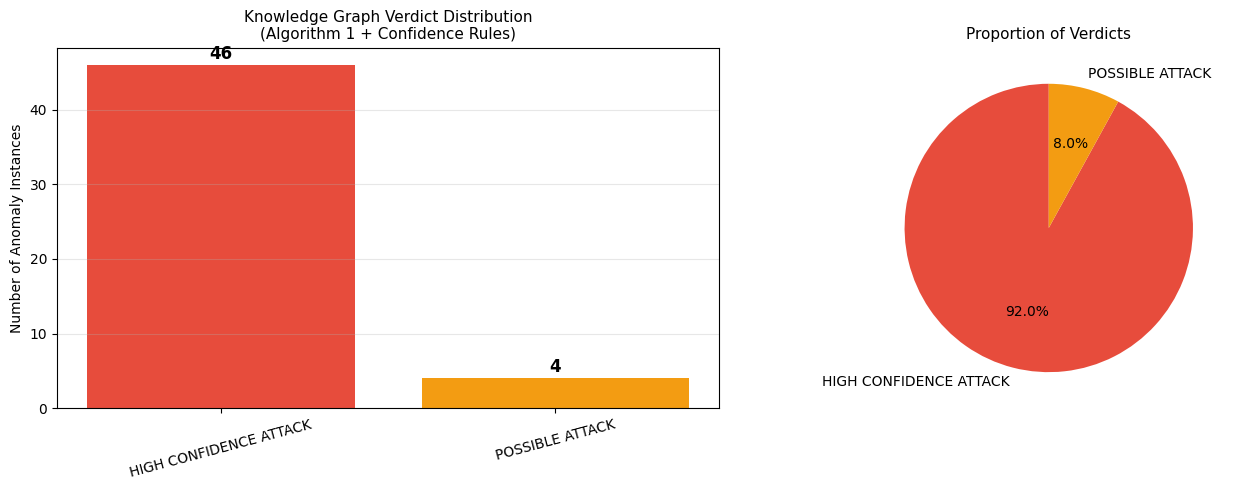

Saved: kg_verdict_distribution.png


In [44]:
verdict_counts = df_results['verdict'].value_counts()

colours = {
    'HIGH CONFIDENCE ATTACK' : '#E74C3C',
    'POSSIBLE ATTACK'        : '#F39C12',
    'LIKELY FALSE POSITIVE'  : '#2ECC71',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars = ax.bar(
    verdict_counts.index,
    verdict_counts.values,
    color=[colours.get(v, '#95A5A6') for v in verdict_counts.index]
)
for bar, val in zip(bars, verdict_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('Knowledge Graph Verdict Distribution\n(Algorithm 1 + Confidence Rules)', fontsize=11)
ax.set_ylabel('Number of Anomaly Instances')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.pie(
    verdict_counts.values,
    labels=verdict_counts.index,
    colors=[colours.get(v, '#95A5A6') for v in verdict_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10}
)
ax.set_title('Proportion of Verdicts', fontsize=11)

plt.tight_layout()
plt.savefig('kg_verdict_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: kg_verdict_distribution.png')

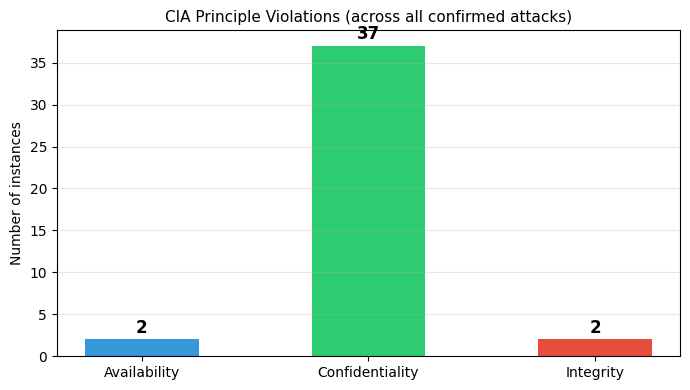

Saved: kg_cia_violations.png


In [45]:
cia_counts = defaultdict(int)
cia_full   = {'C': 'Confidentiality', 'I': 'Integrity', 'A': 'Availability'}

for _, row in df_results.iterrows():
    for c in row['confirmed_cia']:
        cia_counts[cia_full.get(c, c)] += 1

if cia_counts:
    fig, ax = plt.subplots(figsize=(7, 4))
    cia_labels = list(cia_counts.keys())
    cia_vals   = list(cia_counts.values())
    cia_colors = ['#3498DB', '#2ECC71', '#E74C3C'][:len(cia_labels)]

    bars = ax.bar(cia_labels, cia_vals, color=cia_colors, width=0.5)
    for bar, val in zip(bars, cia_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
    ax.set_title('CIA Principle Violations (across all confirmed attacks)', fontsize=11)
    ax.set_ylabel('Number of instances')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('kg_cia_violations.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: kg_cia_violations.png')
else:
    print('No CIA violations confirmed — all instances are false positives.')

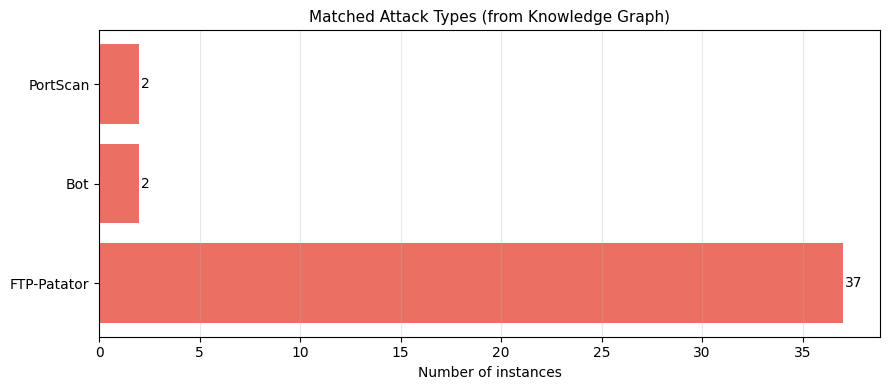

Saved: kg_attack_types.png


In [46]:
attack_counts = defaultdict(int)
for _, row in df_results.iterrows():
    for a in row['confirmed_attacks']:
        attack_counts[a] += 1

if attack_counts:
    sorted_attacks = sorted(attack_counts.items(), key=lambda x: x[1], reverse=True)
    attack_names   = [a[0] for a in sorted_attacks]
    attack_vals    = [a[1] for a in sorted_attacks]

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.barh(attack_names, attack_vals, color='#E74C3C', alpha=0.8)
    for bar, val in zip(bars, attack_vals):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=10)
    ax.set_title('Matched Attack Types (from Knowledge Graph)', fontsize=11)
    ax.set_xlabel('Number of instances')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('kg_attack_types.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: kg_attack_types.png')
else:
    print('No attack types matched — check your threshold CSV and feature name alignment.')

In [47]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns


df_eval = df_results.copy()
df_eval['ground_truth'] = 1 

df_eval['kg_predicted'] = df_eval['verdict_id'].apply(lambda v: 1 if v >= 1 else 0)

y_true = df_eval['ground_truth'].values
y_pred = df_eval['kg_predicted'].values

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)

print('=== Knowledge Graph Accuracy Evaluation ===\n')
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1 Score  : {f1:.4f}')

=== Knowledge Graph Accuracy Evaluation ===

  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000


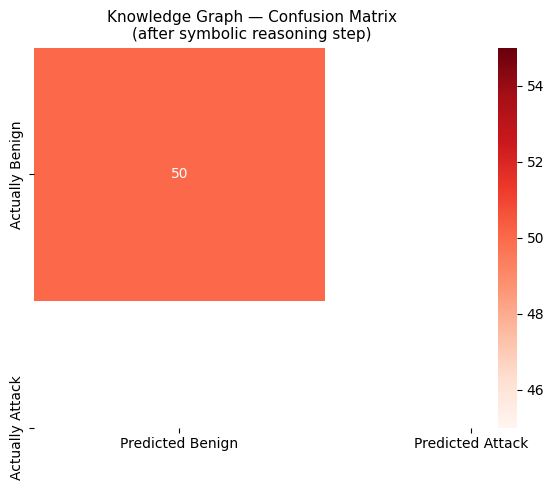

In [48]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Benign', 'Predicted Attack'],
            yticklabels=['Actually Benign', 'Actually Attack'],
            ax=ax)
ax.set_title('Knowledge Graph — Confusion Matrix\n'
             '(after symbolic reasoning step)', fontsize=11)
plt.tight_layout()
plt.savefig('kg_confusion_matrix.png', dpi=150)
plt.show()

## Module 3 Summary

| Item | Details |
|------|---------|
| Algorithm | Algorithm 1, lines 7–12 (Kalutharage et al. 2025) |
| Core rule | `IF kg.nodes[feature]['threshold'] < original_value THEN attack confirmed` |
| Confidence rules | ≥2 confirmed → HIGH · 1 confirmed → POSSIBLE · 0 → FALSE POSITIVE |
| Graph nodes | All features from `kg_feature_thresholds.csv` |
| Domain nodes | 22 features from paper Table 2 (with CIA + attack mappings) |
| Edges | Features sharing ≥1 attack type connected via `same_attack` edge |

### What each file is for

| File | Used by |
|------|---------|
| `kg_reasoning_results.csv` | Module 4 — MITRE ATT&CK mapping |
| `knowledge_graph.graphml` | Gephi / Cytoscape visualisation |
| `knowledge_graph.png` | Report / presentation |
